In [2]:
import zipfile, os

zip_path = "/content/archive_2.zip"
extract_path = "/content/crackforest"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)


Extracted to: /content/crackforest


In [10]:
!pip install ultralytics --quiet


In [11]:
import cv2, glob, os
import numpy as np

IMG_DIR = "/content/crackforest/Images/"
MASK_DIR = "/content/crackforest/Masks/"

# Create YOLO dataset folders
os.makedirs("/content/yolo/images", exist_ok=True)
os.makedirs("/content/yolo/labels", exist_ok=True)

image_paths = sorted(glob.glob(IMG_DIR + "/*.jpg"))
mask_paths  = sorted(glob.glob(MASK_DIR + "/*.png") + glob.glob(MASK_DIR + "/*.PNG"))

for img_path, mask_path in zip(image_paths, mask_paths):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, mask = cv2.threshold(mask, 25, 255, cv2.THRESH_BINARY)

    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        continue

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    x_center = (x1 + x2) / 2 / w
    y_center = (y1 + y2) / 2 / h
    bbox_w = (x2 - x1) / w
    bbox_h = (y2 - y1) / h

    base = os.path.basename(img_path).replace(".jpg", "")
    cv2.imwrite(f"/content/yolo/images/{base}.jpg", img)

    with open(f"/content/yolo/labels/{base}.txt", "w") as f:
        f.write(f"0 {x_center} {y_center} {bbox_w} {bbox_h}")

# Create YOLO data.yaml
yaml_text = """train: /content/yolo/images
val: /content/yolo/images
names: ["crack"]
nc: 1
"""
open("/content/yolo/data.yaml", "w").write(yaml_text)

print("YOLO dataset prepared.")


YOLO dataset prepared.


In [12]:
!yolo detect train data=/content/yolo/data.yaml model=yolov8n.pt epochs=20 imgsz=640 batch=16


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

In [14]:
!yolo detect val model=runs/detect/train3/weights/best.pt data=/content/yolo/data.yaml


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2342.8±614.8 MB/s, size: 57.6 KB)
val: Scanning /content/yolo/labels.cache... 118 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.7it/s 1.7s
                   all        118        118        0.5      0.619      0.617      0.327
Speed: 2.8ms preprocess, 3.7ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [15]:
import cv2, glob, numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

IMG_DIR = "/content/crackforest/Images/"
MASK_DIR = "/content/crackforest/Masks/"
IMG_SIZE = 128

# ------------------- Build U-Net -------------------
def build_unet(input_size=(128,128,3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(c3)
    concat1 = layers.Concatenate()([u1, c2])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat1)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2,2))(c4)
    concat2 = layers.Concatenate()([u2, c1])
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(concat2)
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return models.Model(inputs, outputs)

# ------------------- Load Data -------------------
images, masks = [], []

image_paths = sorted(glob.glob(IMG_DIR + "/*.jpg"))
mask_paths  = sorted(glob.glob(MASK_DIR + "/*.png") + glob.glob(MASK_DIR + "/*.PNG"))

for img_p, mask_p in zip(image_paths, mask_paths):
    img = cv2.imread(img_p)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    _, mask = cv2.threshold(mask, 25, 255, cv2.THRESH_BINARY)
    mask = np.expand_dims(mask / 255.0, axis=-1)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks  = np.array(masks)

X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

# ------------------- Compile & Train -------------------
unet = build_unet()
unet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
unet.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=8)

# ------------------- Evaluate -------------------
metrics_unet = unet.evaluate(X_val, y_val)
print("U-Net Validation Loss/Accuracy:", metrics_unet)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 613ms/step - accuracy: 0.9722 - loss: 0.6449 - val_accuracy: 0.9772 - val_loss: 0.5995
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9793 - loss: 0.5739 - val_accuracy: 0.9772 - val_loss: 0.4536
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9808 - loss: 0.3677 - val_accuracy: 0.9772 - val_loss: 0.1334
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9803 - loss: 0.1206 - val_accuracy: 0.9772 - val_loss: 0.1524
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9788 - loss: 0.1328 - val_accuracy: 0.9772 - val_loss: 0.1228
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9796 - loss: 0.1101 - val_accuracy: 0.9772 - val_loss: 0.1187
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9802 - loss: 0.1064 - val_accuracy: 0.9772 - val_loss: 0.1167
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9789 - loss: 0.1084 - val_accuracy: 0.9772 -

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2, glob, numpy as np
from sklearn.model_selection import train_test_split

# -------- SRCNN model --------
def srcnn():
    i = layers.Input(shape=(None, None, 3))
    x = layers.Conv2D(64, 9, activation='relu', padding='same')(i)
    x = layers.Conv2D(32, 1, activation='relu', padding='same')(x)
    x = layers.Conv2D(3, 5, activation='linear', padding='same')(x)
    return models.Model(i, x)

model_srcnn = srcnn()
model_srcnn.compile(optimizer="adam", loss="mse")

IMG_DIR = "/content/crackforest/Images/"

hr_list, lr_list = [], []

for p in sorted(glob.glob(IMG_DIR + "/*.jpg")):
    hr = cv2.imread(p)
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)
    h, w = hr.shape[:2]

    lr = cv2.resize(hr, (w//2, h//2))
    lr = cv2.resize(lr, (w, h))

    hr_list.append(hr / 255.0)
    lr_list.append(lr / 255.0)

hr_list = np.array(hr_list)
lr_list = np.array(lr_list)

lr_train, lr_val, hr_train, hr_val = train_test_split(lr_list, hr_list, test_size=0.2, random_state=42)

# Train
model_srcnn.fit(lr_train, hr_train, validation_data=(lr_val, hr_val), epochs=10, batch_size=4)

# Evaluate
mse_srcnn = model_srcnn.evaluate(lr_val, hr_val)
print("SRCNN Validation MSE:", mse_srcnn)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - loss: 0.0517 - val_loss: 0.0055
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0044 - val_loss: 0.0046
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0032 - val_loss: 0.0035
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0027 - val_loss: 0.0032
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0022 - val_loss: 0.0029
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0023 - val_loss: 0.0028
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0020 - val_loss: 0.0027
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0027
SRCNN Validation MSE: 0.002732296474277973


In [19]:
import pandas as pd

# YOLOv8 metrics from validation
yolo_precision = 0.500
yolo_recall    = 0.619
yolo_map50     = 0.617

# U-Net metrics from evaluation
unet_loss = metrics_unet[0]
unet_accuracy  = metrics_unet[1]

# SRCNN metrics from evaluation
srcnn_mse = mse_srcnn


comparison = pd.DataFrame({
    "Model": ["YOLOv8", "U-Net", "SRCNN"],
    "Precision / Loss / MSE": [yolo_precision, unet_loss, srcnn_mse],
    "Recall / Accuracy / -": [yolo_recall, unet_accuracy, None],
    "mAP50 / - / -": [yolo_map50, None, None]
})

comparison


,Model,Precision / Loss / MSE,Recall / Accuracy / -,mAP50 / - / -
0,YOLOv8,0.500000,0.619000,0.617
1,U-Net,0.104916,0.977226,NaN
2,SRCNN,0.002732,NaN,NaN


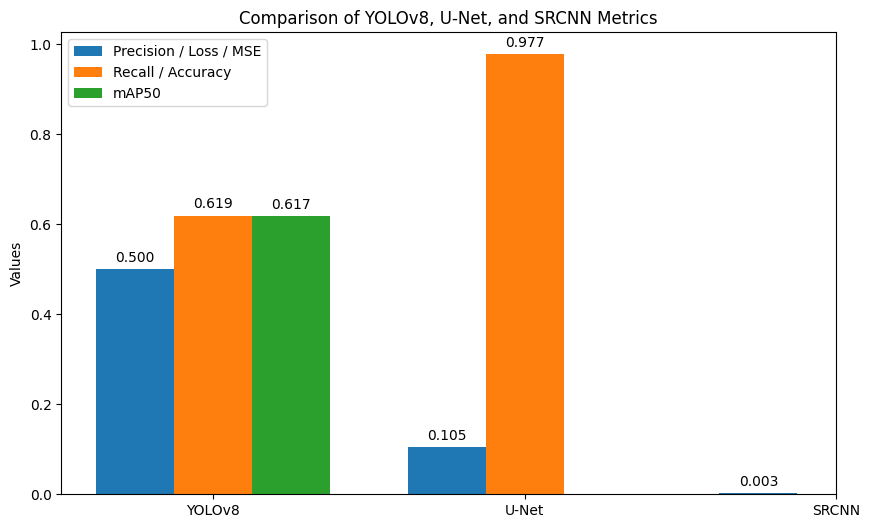

In [20]:
import matplotlib.pyplot as plt
import numpy as np

models = ["YOLOv8", "U-Net", "SRCNN"]

# Corresponding metrics
metric1 = [yolo_precision, unet_loss, srcnn_mse]  # Precision / Loss / MSE
metric2 = [yolo_recall, unet_accuracy, np.nan]     # Recall / Accuracy
metric3 = [yolo_map50, np.nan, np.nan]            # mAP50

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width, metric1, width, label='Precision / Loss / MSE')
rects2 = ax.bar(x, metric2, width, label='Recall / Accuracy')
rects3 = ax.bar(x + width, metric3, width, label='mAP50')

ax.set_ylabel('Values')
ax.set_title('Comparison of YOLOv8, U-Net, and SRCNN Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate bars
def annotate(rects):
    for rect in rects:
        height = rect.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

annotate(rects1)
annotate(rects2)
annotate(rects3)

plt.show()
